In [13]:
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from matplotlib import pyplot as plt

from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, Rescaling, RandomFlip, RandomRotation, RandomZoom, RandomTranslation, Dropout

from keras.utils import image_dataset_from_directory
from keras.models import Sequential

# Nuevos
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
from tensorflow.keras.applications import VGG16, ResNet50, InceptionV3
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.applications.vgg16 import preprocess_input as vgg16_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet50_preprocess
from tensorflow.keras.applications.inception_v3 import preprocess_input as inception_preprocess


---
# Parte 1: Preparación

## 1. Carga del dataset
Utiliza la función load_data() para cargar el dataset CIFAR-10 (la función está en tensorflow.keras.datasets.cifar10).

In [14]:
datos = cifar10.load_data()

## 2. Preprocesamiento de Datos
Normaliza las imágenes (escalar los valores de píxeles entre 0 y 1) y convierte las etiquetas a formato one-hot.

In [ ]:
(x_train, y_train), (x_test, y_test) = datos

'\nX_train = x_train / 255.0\nX_test = x_test / 255.0\n'

In [17]:
# Convertir etiquetas a one-hot encoding
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

# Verificar dimensiones
print("Forma de x_train:", x_train.shape)
print("Forma de y_train:", y_train.shape)
print("Forma de x_test:", x_test.shape)
print("Forma de y_test:", y_test.shape)

# Obtener tamaños imágenes
IMG_SIZE = x_train[0].shape

Forma de x_train: (50000, 32, 32, 3)
Forma de y_train: (50000, 10)
Forma de x_test: (10000, 32, 32, 3)
Forma de y_test: (10000, 10)


In [18]:
X_train = x_train.copy()
X_test = x_test.copy()

# VGG16
X_train_vgg16 = vgg16_preprocess(X_train.copy())
X_test_vgg16 = vgg16_preprocess(X_test.copy())

# Resnet
X_train_resnet50 = resnet50_preprocess(X_train.copy())
X_test_resnet50 = resnet50_preprocess(X_test.copy())

# Inception
X_train_inception = inception_preprocess(X_train.copy())
X_test_inception = inception_preprocess(X_test.copy())

X_train_inception = tf.image.resize(X_train_inception, (75, 75))
X_test_inception = tf.image.resize(X_test_inception, (75, 75))

---
# Parte 2: Implementación y entrenamiento

## 1. Arquitecturas
Utilizaremos VGG16, ResNet50 e InceptionV3.

In [19]:
modelo_vgg = VGG16(weights='imagenet', include_top=False, input_shape=IMG_SIZE)
modelo_resnet = ResNet50(weights='imagenet', include_top=False, input_shape=IMG_SIZE)
modelo_inception = InceptionV3(weights='imagenet', include_top=False, input_shape=(75, 75, 3))

lista_modelos = [modelo_vgg, modelo_resnet, modelo_inception]

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## 2. Preparación de las arquitecturas
Carga cada uno de los modelos preentrenados sin las capas superiores (sin la capa de clasificación) y congela todas las capas.

In [20]:
for modelo in lista_modelos:
    for layer in modelo.layers:
        layer.trainable = False

## 3. Construcción
 - VGG16: Usa VGG16 preentrenado en imagenes de ImageNet.
 - ResNet50: Usa ResNet50 preentrenado.
 - InceptionV3: Usa InceptionV3 preentrenado.

In [21]:
capas_densas_modelos = []

for modelo in lista_modelos:
    x = Flatten()(modelo.output)
    x = Dense(1024, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.3)(x)
    x = Dense(10, activation='softmax')(x)

    capas_densas_modelos.append(x)

## 4. Compilación
Utiliza el optimizador Adam y la función de pérdida categorical_crossentropy.

In [ ]:
modelos_con_capas = (lista_modelos, capas_densas_modelos)
print(lista_modelos)
print(modelos_con_capas[0])
print(modelos_con_capas[1])
print(modelos_con_capas[1][0])

[<Functional name=vgg16, built=True>, <Functional name=resnet50, built=True>, <Functional name=inception_v3, built=True>]
[<Functional name=vgg16, built=True>, <Functional name=resnet50, built=True>, <Functional name=inception_v3, built=True>]
[<KerasTensor shape=(None, 10), dtype=float32, sparse=False, name=keras_tensor_510>, <KerasTensor shape=(None, 10), dtype=float32, sparse=False, name=keras_tensor_516>, <KerasTensor shape=(None, 10), dtype=float32, sparse=False, name=keras_tensor_522>]
<KerasTensor shape=(None, 10), dtype=float32, sparse=False, name=keras_tensor_510>


'\nmodelos_con_capas = {\n    "lista_modelos": lista_modelos,\n    "capas_densas_modelos": capas_densas_modelos\n}\n'

In [ ]:
# Modelo VGG16
modelo_vgg_compilado = Model(inputs=modelos_con_capas[0][0].input, outputs=modelos_con_capas[1][0])
modelo_vgg_compilado.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])
modelo_vgg_compilado.summary()


# Modelo ResNet50
modelo_resnet_compilado = Model(inputs=modelos_con_capas[0][1].input, outputs=modelos_con_capas[1][1])
modelo_resnet_compilado.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])
modelo_resnet_compilado.summary()


# Modelo InceptionV3
modelo_inception_compilado = Model(inputs=modelos_con_capas[0][2].input, outputs=modelos_con_capas[1][2])
modelo_inception_compilado.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])
modelo_inception_compilado.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 32, 32, 64)          │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 32, 32, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 16, 16, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 16, 16, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 8, 8, 256)           │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 8, 8, 256)           │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 8, 8, 256)           │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 4, 4, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 4, 4, 512)           │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 4, 4, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 4, 4, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 2, 2, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 2, 2, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 2, 2, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 2, 2, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 1, 1, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1024)                │         525,312 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 15,769,930 (60.16 MB)

 Trainable params: 1,055,242 (4.03 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

...

 Total params: 26,215,818 (100.01 MB)

 Trainable params: 2,628,106 (10.03 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Model: "functional_2"

 Non-trainable params: 21,802,784 (83.17 MB)

## 5. Entrenamiento
Entrena cada modelo con las imágenes del conjunto de entrenamiento y evalúa en el conjunto de test. Ajusta el número de épocas según sea necesario.

In [28]:
epochs = 10
batch_size = 32

In [29]:
# Entrenamiento del modelo VGG16
historia_vgg16 = modelo_vgg_compilado.fit(
    X_train_vgg16, y_train,
    validation_data=(X_test_vgg16, y_test),
    epochs=epochs,
    batch_size=batch_size,
    verbose=1
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - accuracy: 0.3384 - loss: 6.3657 - val_accuracy: 0.5052 - val_loss: 1.5229
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.4630 - loss: 1.6741 - val_accuracy: 0.5667 - val_loss: 1.3300
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.5280 - loss: 1.3734 - val_accuracy: 0.6061 - val_loss: 1.2031
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.5739 - loss: 1.2302 - val_accuracy: 0.6363 - val_loss: 1.1162
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.6019 - loss: 1.1426 - val_accuracy: 0.6495 - val_loss: 1.0744
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.6257 - loss: 1.0676 - val_accuracy: 0.6608 - val_loss: 1.0314
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.6448 - loss: 1.0089 - val_accuracy: 0.6689 - val_loss: 1.0006
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.6569 - loss: 

In [30]:
# Entrenamiento del modelo ResNet50
historia_resnet50 = modelo_resnet_compilado.fit(
    X_train_resnet50, y_train,
    validation_data=(X_test_resnet50, y_test),
    epochs=epochs,
    batch_size=batch_size,
    verbose=1
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 34s 15ms/step - accuracy: 0.4008 - loss: 2.2483 - val_accuracy: 0.6143 - val_loss: 1.1278
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.5836 - loss: 1.1975 - val_accuracy: 0.6412 - val_loss: 1.0398
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.6279 - loss: 1.0527 - val_accuracy: 0.6533 - val_loss: 0.9887
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.6608 - loss: 0.9685 - val_accuracy: 0.6640 - val_loss: 0.9583
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.6865 - loss: 0.8910 - val_accuracy: 0.6704 - val_loss: 0.9375
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.7076 - loss: 0.8227 - val_accuracy: 0.6773 - val_loss: 0.9185
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.7293 - loss: 0.7609 - val_accuracy: 0.6839 - val_loss: 0.9062
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.7447 - loss: 

In [31]:
# Entrenamiento del modelo InceptionV3
historia_inceptionv3 = modelo_inception_compilado.fit(
    X_train_inception, y_train,
    validation_data=(X_test_inception, y_test),
    epochs=epochs,
    batch_size=batch_size,
    verbose=1
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 52s 24ms/step - accuracy: 0.3914 - loss: 1.7575 - val_accuracy: 0.6182 - val_loss: 1.0966
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.5981 - loss: 1.1465 - val_accuracy: 0.6371 - val_loss: 1.0335
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.6472 - loss: 1.0100 - val_accuracy: 0.6519 - val_loss: 0.9923
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.6730 - loss: 0.9268 - val_accuracy: 0.6589 - val_loss: 0.9695
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.6973 - loss: 0.8596 - val_accuracy: 0.6688 - val_loss: 0.9572
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.7208 - loss: 0.7897 - val_accuracy: 0.6722 - val_loss: 0.9510
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.7437 - loss: 0.7269 - val_accuracy: 0.6732 - val_loss: 0.9595
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.7697 -

---
# Parte 3: Evaluación

## 1. Obtención de métricas
Evalúa los tres modelos utilizando el conjunto de prueba y compara su precisión. Genera las gráficas de pérdida y precisión, así como la matriz de confusión y el informe de clasificación.

In [32]:
def obtenerMetricas(modelo, x_train):
    # Obtener las etiquetas verdaderas
    y_true = np.argmax(y_train, axis=1)
    
    # Predecir con el modelo
    y_pred = modelo.predict(x_train)
    y_pred = np.argmax(y_pred, axis=1)  # Obtener la clase con mayor probabilidad
    
    # Nombres de las clases (ajusta según tu dataset)
    target_names = [f"Clase {i}" for i in range(10)]  
    
    # Reporte de clasificación
    print(classification_report(y_true, y_pred, target_names=target_names))
    
    # Matriz de confusión
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.title("Matriz de Confusión")
    plt.show()

In [33]:
def graficarEvolucionModelo(modelo, history, x_test):
    # Evaluación del modelo en el conjunto de test
    loss, accuracy = modelo.evaluate(x_test, y_test)
    
    print(f"Pérdida en test: {loss:.4f}")
    print(f"Precisión en test: {accuracy:.4f}")
    
    # Extraer los valores del historial
    train_loss = history.history['loss']
    val_loss = history.history['val_loss']
    train_acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    epochs_range = range(len(train_loss))
    
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, train_loss, label='Pérdida de entrenamiento')
    plt.plot(epochs_range, val_loss, label='Pérdida de validación')
    plt.xlabel('Épocas')
    plt.ylabel('Pérdida')
    plt.legend()
    plt.title('Evolución de la Pérdida')
    
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, train_acc, label='Precisión de entrenamiento')
    plt.plot(epochs_range, val_acc, label='Precisión de validación')
    plt.xlabel('Épocas')
    plt.ylabel('Precisión')
    plt.legend()
    plt.title('Evolución de la Precisión')
    
    plt.show()


### Modelo: VGG16

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step
              precision    recall  f1-score   support

     Clase 0       0.85      0.80      0.82      5000
     Clase 1       0.82      0.82      0.82      5000
     Clase 2       0.76      0.69      0.72      5000
     Clase 3       0.67      0.61      0.64      5000
     Clase 4       0.73      0.70      0.72      5000
     Clase 5       0.73      0.66      0.69      5000
     Clase 6       0.74      0.86      0.79      5000
     Clase 7       0.73      0.83      0.78      5000
     Clase 8       0.87      0.86      0.86      5000
     Clase 9       0.78      0.84      0.81      5000

    accuracy                           0.77     50000
   macro avg       0.77      0.77      0.77     50000
weighted avg       0.77      0.77      0.77     50000



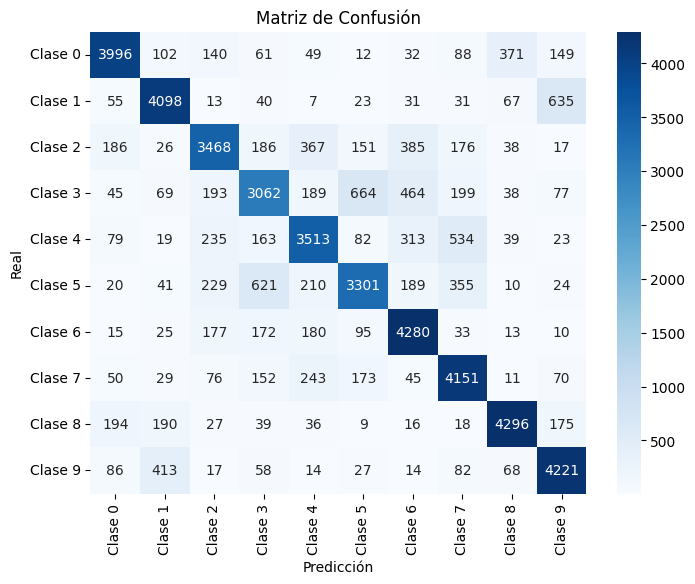

In [34]:
obtenerMetricas(modelo_vgg_compilado, X_train_vgg16)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6826 - loss: 0.9436
Pérdida en test: 0.9437
Precisión en test: 0.6832


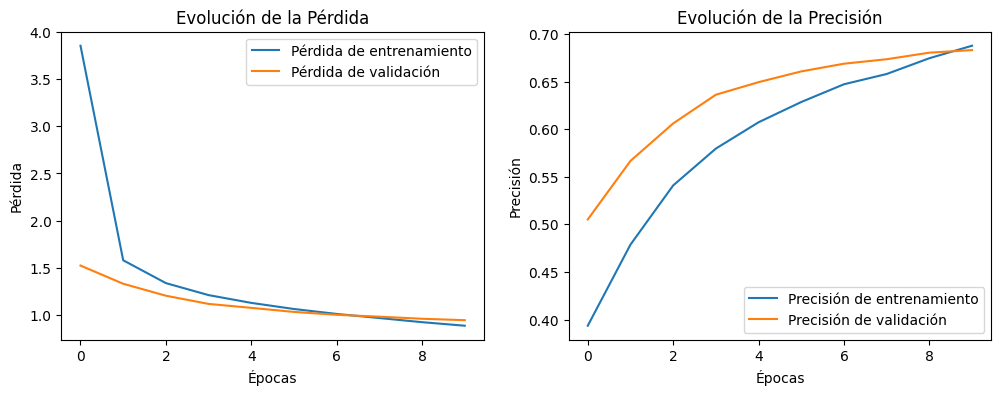

In [35]:
graficarEvolucionModelo(modelo_vgg_compilado, historia_vgg16, X_test_vgg16)

### Modelo: ResNet50

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step
              precision    recall  f1-score   support

     Clase 0       0.90      0.92      0.91      5000
     Clase 1       0.87      0.90      0.88      5000
     Clase 2       0.93      0.84      0.88      5000
     Clase 3       0.87      0.78      0.82      5000
     Clase 4       0.84      0.88      0.86      5000
     Clase 5       0.82      0.87      0.84      5000
     Clase 6       0.91      0.93      0.92      5000
     Clase 7       0.88      0.91      0.89      5000
     Clase 8       0.93      0.92      0.93      5000
     Clase 9       0.89      0.87      0.88      5000

    accuracy                           0.88     50000
   macro avg       0.88      0.88      0.88     50000
weighted avg       0.88      0.88      0.88     50000



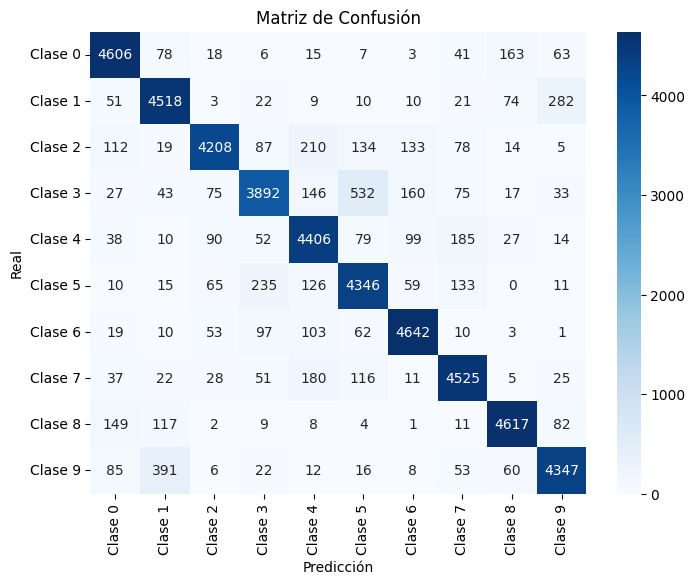

In [36]:
obtenerMetricas(modelo_resnet_compilado, X_train_resnet50)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6802 - loss: 0.9201
Pérdida en test: 0.9069
Precisión en test: 0.6881


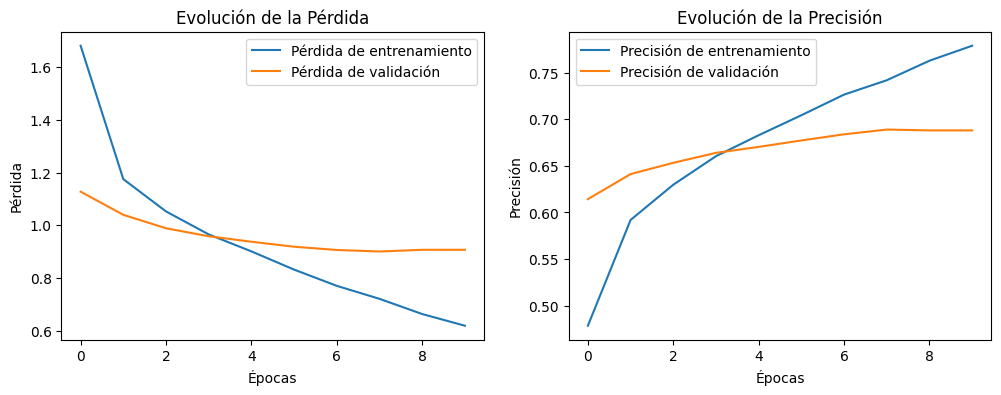

In [37]:
graficarEvolucionModelo(modelo_resnet_compilado, historia_resnet50, X_test_resnet50)

### Modelo: InceptionV3

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step
              precision    recall  f1-score   support

     Clase 0       0.91      0.93      0.92      5000
     Clase 1       0.95      0.93      0.94      5000
     Clase 2       0.92      0.85      0.88      5000
     Clase 3       0.82      0.87      0.85      5000
     Clase 4       0.86      0.81      0.84      5000
     Clase 5       0.90      0.87      0.88      5000
     Clase 6       0.87      0.92      0.90      5000
     Clase 7       0.89      0.92      0.90      5000
     Clase 8       0.92      0.94      0.93      5000
     Clase 9       0.92      0.93      0.93      5000

    accuracy                           0.90     50000
   macro avg       0.90      0.90      0.90     50000
weighted avg       0.90      0.90      0.90     50000



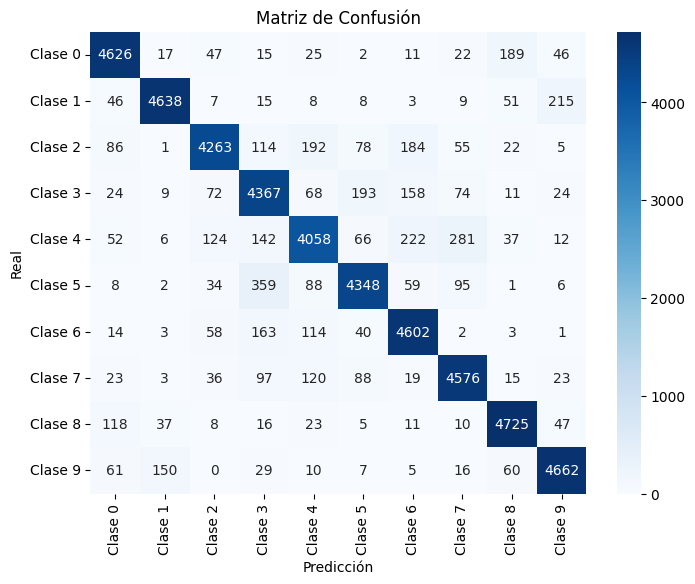

In [38]:
obtenerMetricas(modelo_inception_compilado, X_train_inception)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6780 - loss: 1.0239
Pérdida en test: 1.0087
Precisión en test: 0.6761


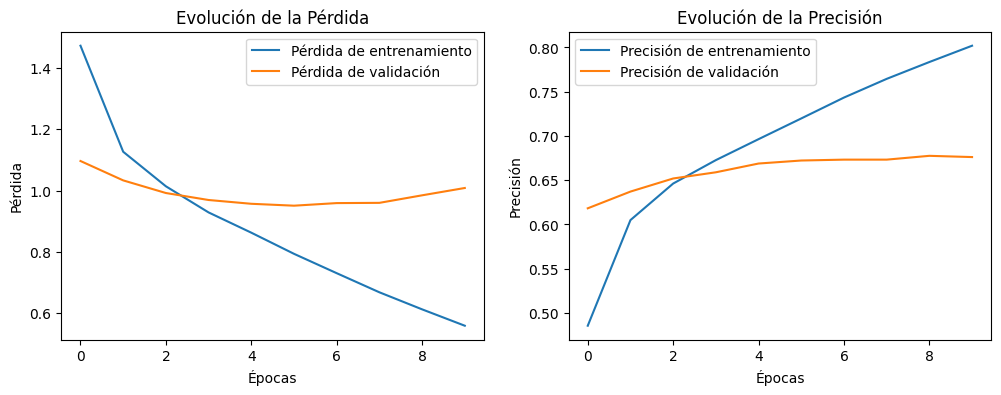

In [39]:
graficarEvolucionModelo(modelo_inception_compilado, historia_inceptionv3, X_test_inception)